In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [4]:
Boston = load_data("Boston")
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [6]:
y = Boston["crim"]
columns = Boston.columns.drop("crim")
columns

Index(['zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

Results for crim vs zn: 
              coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0 




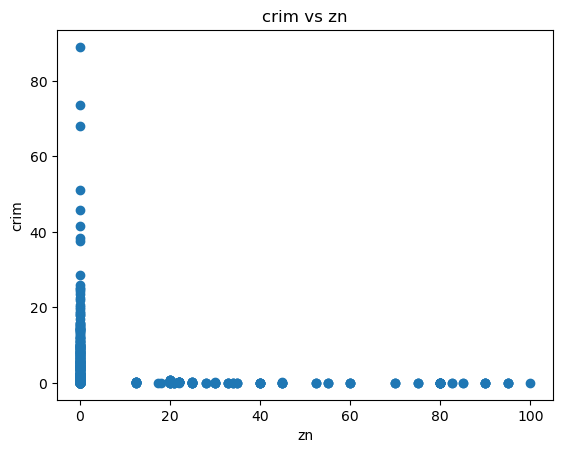

Results for crim vs indus: 
              coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000 




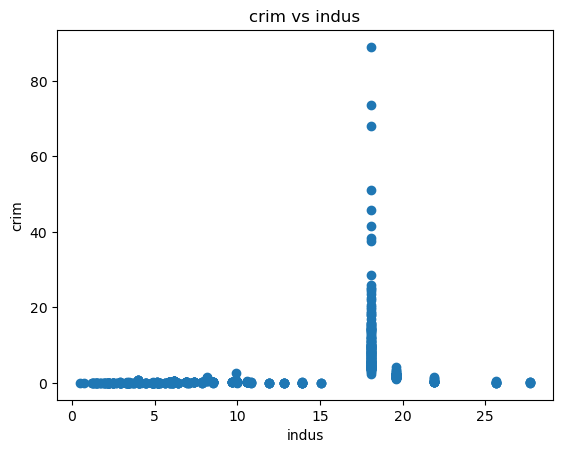

Results for crim vs chas: 
              coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209 




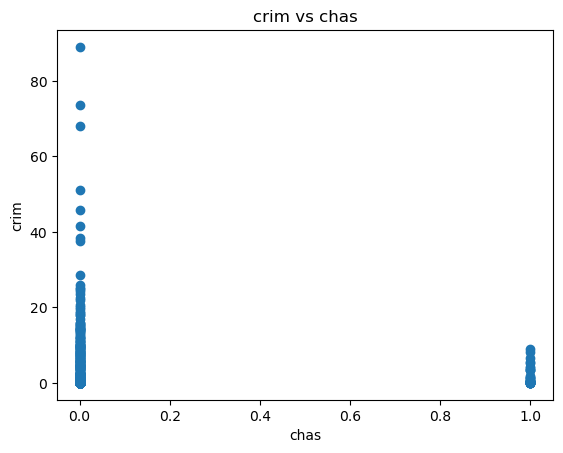

Results for crim vs nox: 
               coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0 




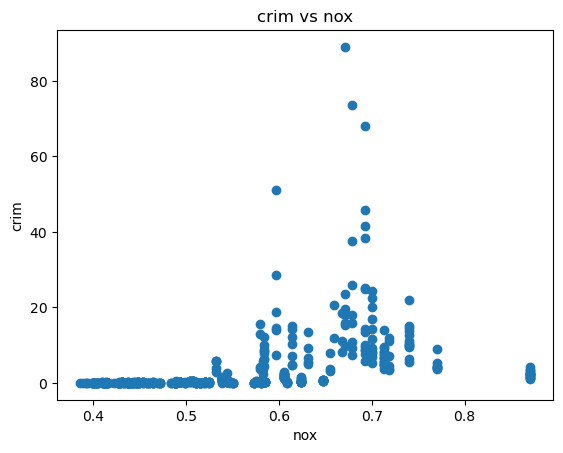

Results for crim vs rm: 
               coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0 




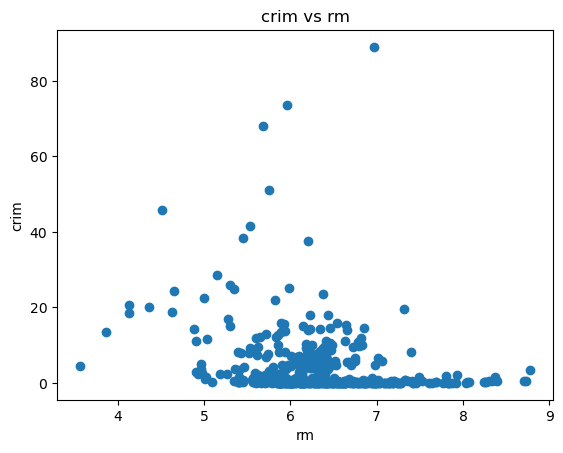

Results for crim vs age: 
              coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0 




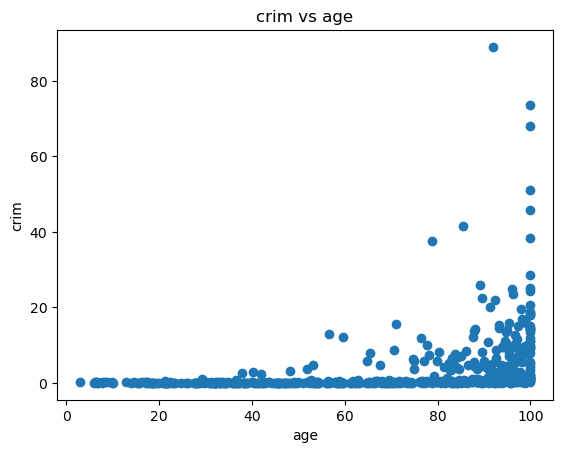

Results for crim vs dis: 
              coef  std err       t  P>|t|
intercept  9.4993    0.730  13.006    0.0
dis       -1.5509    0.168  -9.213    0.0 




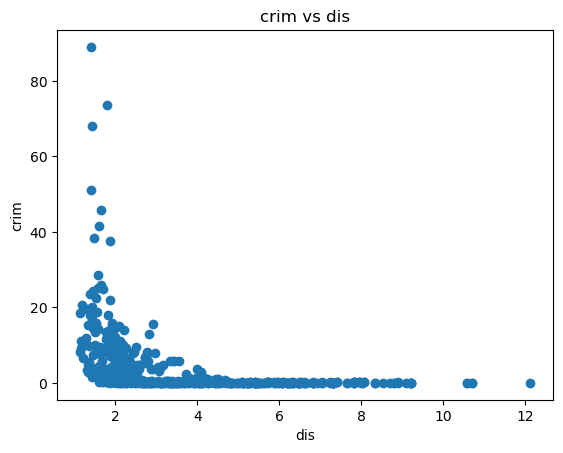

Results for crim vs rad: 
              coef  std err       t  P>|t|
intercept -2.2872    0.443  -5.157    0.0
rad        0.6179    0.034  17.998    0.0 




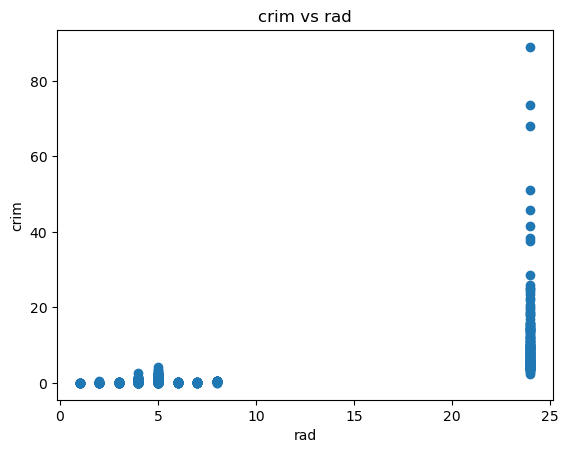

Results for crim vs tax: 
              coef  std err       t  P>|t|
intercept -8.5284    0.816 -10.454    0.0
tax        0.0297    0.002  16.099    0.0 




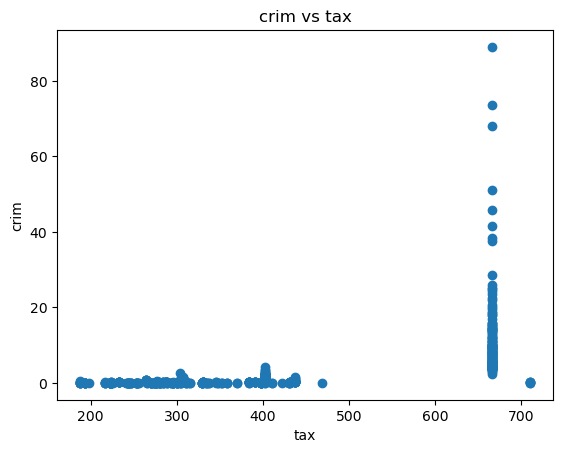

Results for crim vs ptratio: 
               coef  std err      t  P>|t|
intercept -17.6469    3.147 -5.607    0.0
ptratio     1.1520    0.169  6.801    0.0 




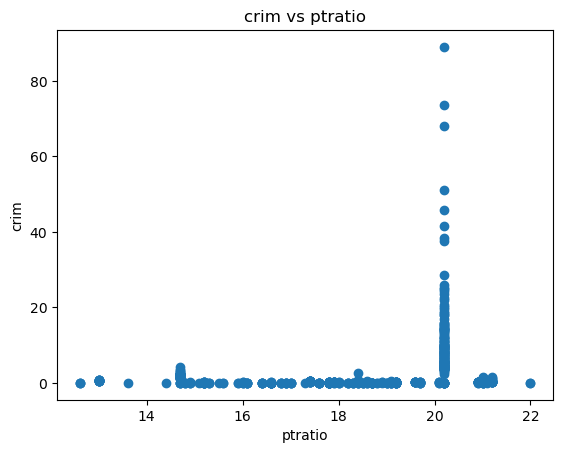

Results for crim vs lstat: 
              coef  std err       t  P>|t|
intercept -3.3305    0.694  -4.801    0.0
lstat      0.5488    0.048  11.491    0.0 




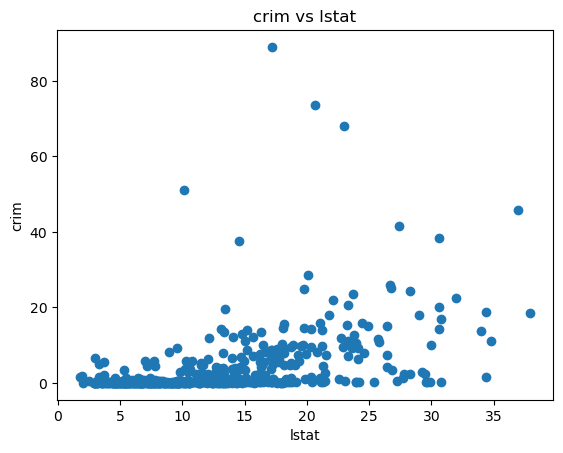

Results for crim vs medv: 
               coef  std err       t  P>|t|
intercept  11.7965    0.934  12.628    0.0
medv       -0.3632    0.038  -9.460    0.0 




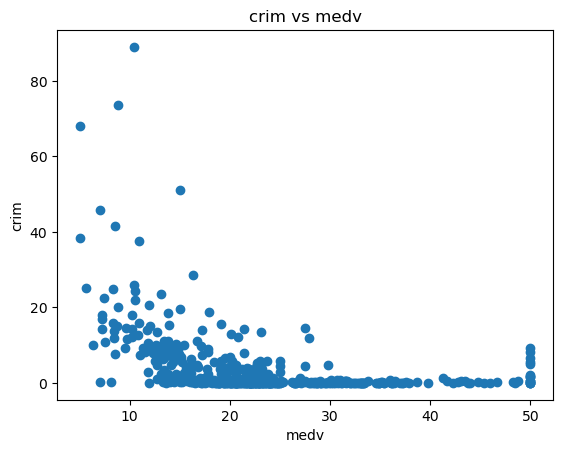

In [17]:
results_single = []
for var in columns:
    X = MS([var]).fit_transform(Boston)
    model = sm.OLS(y, X)
    results = model.fit()
    results_single.append(results)
    print(f"Results for crim vs {var}: \n {summarize(results)} \n\n")
    plt.figure()
    plt.scatter(Boston[var], y)
    plt.title(f"crim vs {var}")
    plt.xlabel(f"{var}")
    plt.ylabel("crim")
    plt.show()

In [18]:
# for part (b) a multiple regression model using all the predictors
X = MS(columns).fit_transform(Boston)
model = sm.OLS(y, X)
results_multi = model.fit()
summarize(results_multi)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


(b) From the multiple regression model for variables : indus, chas, nox, rm, age, tax, ptratio, lstat, we fail to reject to fail the null hypothesis.

-0.0739
0.5098
-1.8928
31.2485
-2.6841
0.1078
-1.5509
0.6179
0.0297
1.152
0.5488
-0.3632


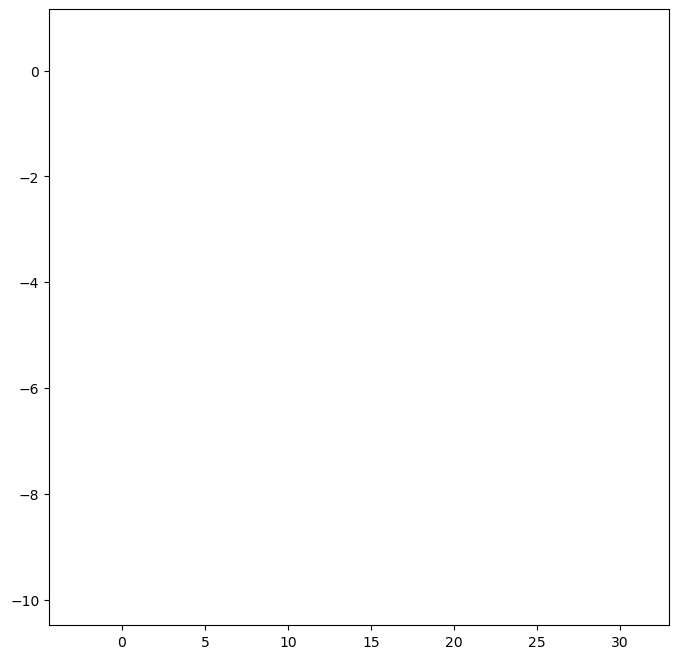

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
for var, results in zip(columns, results_single):
    ax.plot(summarize(results)["coef"][var], summarize(results_multi)["coef"][var])
    print(summarize(results)["coef"][var])

AttributeError: 'OLSResults' object has no attribute 'iloc'